# NB 23 - `test_internal` slice selector for the API showcase

Picks a demo slice that shows **lots of anomaly activity** in the `/timeline`
view, so the FE has something visually interesting to render. Slides a
fixed-length window across `test_internal`, ranks every candidate by anomaly
density, and plots the top picks. A manual slice explorer at the bottom lets you
inspect any row range by hand.

Whether the model *catches* every event isn't the criterion - the FE only needs
a busy-looking section.

## 1 - Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys, time
from pathlib import Path
PROJECT_ROOT = Path('..').resolve()
for p in (PROJECT_ROOT / 'src', PROJECT_ROOT):
    sp = str(p)
    if sp not in sys.path:
        sys.path.insert(0, sp)

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sentinel.ml_logic.data      import load_target_channels, find_anomaly_segments
from sentinel.ml_logic.predictor import predict_report
from sentinel.ml_logic.registry  import load_model, load_scaler
from sentinel.ml_logic.viz       import plot_timeline
from sentinel.params             import PCA_THRESHOLD, PROCESSED_DIR, WINDOW_SIZE, ANOMALY_COLOR, NOMINAL_COLOR

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

print('PCA_THRESHOLD :', PCA_THRESHOLD)
print('WINDOW_SIZE   :', WINDOW_SIZE)
print('PROCESSED_DIR :', PROCESSED_DIR)

PCA_THRESHOLD : 0.060404
WINDOW_SIZE   : 100
PROCESSED_DIR : /Users/helena.schulz.ext/code/alexfederolf/sentinel/data/processed


## 2 - Load PCA artefacts and `test_internal`

Same artefacts the FastAPI service loads at startup. `X_int` / `y_int` is the labelled
internal hold-out (≈2.19 M rows, ~10 % anomalous) - opposed to the unlabelled Kaggle
`test.parquet`.

In [2]:
model    = load_model('pca')
scaler   = load_scaler()
features = load_target_channels()
X_int    = np.load(PROCESSED_DIR / 'test_intern_raw.npy')
y_int    = np.load(PROCESSED_DIR / 'y_test_intern.npy')

print(f'X_int    : {X_int.shape}   {X_int.dtype}')
print(f'y_int    : {y_int.shape}   anomaly rows: {int(y_int.sum()):,} ({y_int.mean():.2%})')

✅ Model loaded ← /Users/helena.schulz.ext/code/alexfederolf/sentinel/models/pca.pkl
✅ Scaler loaded ← /Users/helena.schulz.ext/code/alexfederolf/sentinel/models/scaler.pkl
X_int    : (2186220, 58)   float32
y_int    : (2186220,)   anomaly rows: 214,961 (9.83%)


## 3 - Score the full `test_internal` slice with the API PCA

`predict_report` returns row-level scores (window-mean MSE broadcast to rows), the
binary labels at `PCA_THRESHOLD`, and per-channel diagnostics. Scoring 2.19 M rows
takes a few seconds because PCA is fully vectorised.

In [3]:
t0 = time.time()
rep = predict_report(
    model=model, scaler=scaler, features=features,
    X_raw=X_int, threshold=PCA_THRESHOLD, topk=None,
)
scores = rep['row_scores']
y_pred = rep['labels']
print(f'predict_report : {time.time()-t0:.2f}s')
print(f'predicted anom : {int(y_pred.sum()):,} rows  ({y_pred.mean():.2%})')
print(f'score range    : [{scores.min():.4f}, {scores.max():.4f}]   mean {scores.mean():.4f}')

predict_report : 1.00s
predicted anom : 1,313,720 rows  (60.09%)
score range    : [0.0258, 3.0895]   mean 0.1250


## 4 - Anomaly event inventory

Find every contiguous true-anomaly run. We only need event positions and lengths
to score candidate slices in the next step.

In [4]:
events_df = pd.DataFrame([
    {'start': seg['start'], 'end': seg['end'], 'length': seg['length']}
    for seg in find_anomaly_segments(y_int)
])
n_events  = len(events_df)
ev_starts = events_df['start'].values
ev_ends   = events_df['end'].values

print(f'Total events       : {n_events}')
print(f'Total anomaly rows : {int(y_int.sum()):,} ({y_int.mean():.2%})')
print('\nLength stats:')
print(events_df['length'].describe().round(0).to_string())
events_df.head(10)

Total events       : 27
Total anomaly rows : 214,961 (9.83%)

Length stats:
count       27.0
mean      7962.0
std      16959.0
min          1.0
25%         25.0
50%         67.0
75%       4914.0
max      68341.0


,start,end,length
0,69905,69905,1
1,98664,98688,25
2,400398,401877,1480
3,576150,607979,31830
4,643518,648653,5136
5,830142,840143,10002
6,880531,885222,4692
7,1061595,1074539,12945
8,1095484,1095515,32
9,1096120,1096146,27


## 5 - Candidate slice scoring

Slide a fixed-length window across `test_internal`. For each candidate we record
the event count and the anomaly density (fraction of true-anomaly rows). Density
is the ranking criterion - higher = busier-looking timeline.

`SLICE_LEN` is the main knob; `STRIDE` controls how aggressively the window slides.
Both must be multiples of `WINDOW_SIZE` so the slice begins/ends on a PCA window
boundary (required when we save it as the live `test_api`).

In [5]:
SLICE_LEN = 300_000   # rows per candidate. Bigger = more events / denser visualisation.
STRIDE    = 25_000    # candidate spacing (must be multiple of WINDOW_SIZE)

assert SLICE_LEN % WINDOW_SIZE == 0
assert STRIDE   % WINDOW_SIZE == 0

candidates = []
for s in range(0, len(X_int) - SLICE_LEN + 1, STRIDE):
    e = s + SLICE_LEN
    inside = (ev_starts >= s) & (ev_ends < e)
    candidates.append({
        'start'        : s,
        'end'          : e,
        'n_events'     : int(inside.sum()),
        'anomaly_rate' : float(y_int[s:e].mean()),
    })
cand_df = pd.DataFrame(candidates)
print(f'Total candidate slices: {len(cand_df):,}   ·   SLICE_LEN={SLICE_LEN:,}   STRIDE={STRIDE:,}')
print(cand_df[['n_events', 'anomaly_rate']].describe().round(3))

Total candidate slices: 76   ·   SLICE_LEN=300,000   STRIDE=25,000
       n_events  anomaly_rate
count    76.000        76.000
mean      3.303         0.111
std       2.173         0.132
min       0.000         0.000
25%       2.000         0.005
50%       2.500         0.059
75%       5.000         0.134
max      10.000         0.476


## 6 - Pick the top candidate slices

Sort all candidates by anomaly density and keep the top `TOP_K` non-overlapping
ones so the picks cover well-separated regions. The bar plot underneath shows
**every** candidate (grey) with the picks highlighted, so the FE can see at a
glance where the busy regions of `test_internal` are.

In [6]:
TOP_K = 8

picked = []
for _, row in cand_df.sort_values('anomaly_rate', ascending=False).iterrows():
    overlap = any(not (row['end'] <= p['start'] or row['start'] >= p['end']) for p in picked)
    if overlap:
        continue
    picked.append(row.to_dict())
    if len(picked) >= TOP_K:
        break

picked_df = pd.DataFrame(picked).reset_index(drop=True)
picked_df.insert(0, 'rank', picked_df.index + 1)
print(f'Top {len(picked_df)} non-overlapping slices  ·  sorted by anomaly density')
picked_df

Top 5 non-overlapping slices  ·  sorted by anomaly density


,rank,start,end,n_events,anomaly_rate
0,1,1650000.0,1950000.0,6.0,0.476253
1,2,550000.0,850000.0,3.0,0.156560
2,3,850000.0,1150000.0,6.0,0.059163
3,4,125000.0,425000.0,1.0,0.004933
4,5,1250000.0,1550000.0,3.0,0.002743


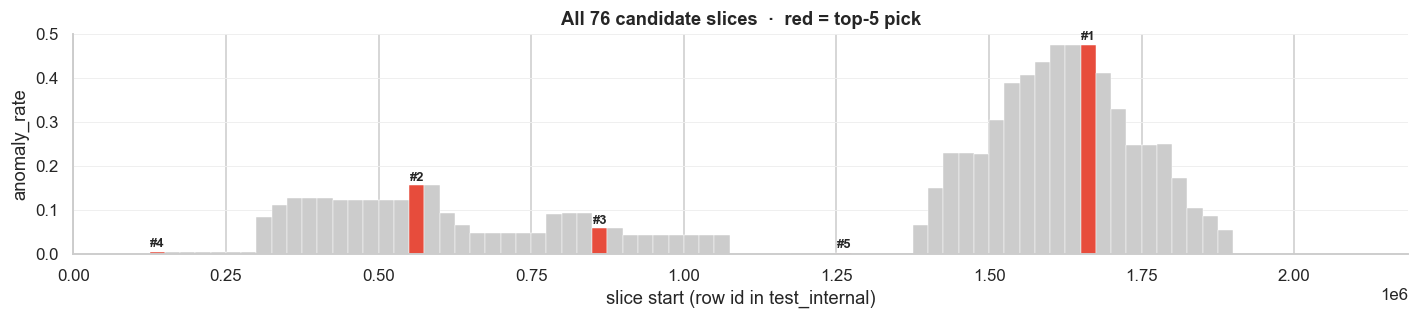

In [7]:
# All candidate slices as bars (grey), top-K picks highlighted (red) with rank labels.
picked_starts = set(int(s) for s in picked_df['start'])
colors = [ANOMALY_COLOR if int(s) in picked_starts else '#cccccc' for s in cand_df['start']]

fig, ax = plt.subplots(figsize=(13, 3.0))
ax.bar(cand_df['start'], cand_df['anomaly_rate'],
       width=STRIDE, color=colors, edgecolor='white', linewidth=0.3, align='edge')

for _, p in picked_df.iterrows():
    ax.annotate(f"#{int(p['rank'])}",
                (p['start'] + STRIDE / 2, p['anomaly_rate']),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=8.5, fontweight='bold')

ax.set_xlim(0, len(X_int))
ax.set_xlabel('slice start (row id in test_internal)')
ax.set_ylabel('anomaly_rate')
ax.set_title(f'All {len(cand_df)} candidate slices  ·  red = top-{len(picked_df)} pick',
             fontweight='bold')
ax.grid(True, axis='y', color='#eeeeee', lw=0.6, zorder=0)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.tight_layout(); plt.show()

## 7 - Timeline plots for the top slices

Each slice is plotted with `plot_timeline` (the same renderer the API showcase uses)
so we can eyeball whether the events are visually distinct and whether the model's
predictions land where they should. `log_y=True` because PCA reconstruction MSE
spans multiple decades.

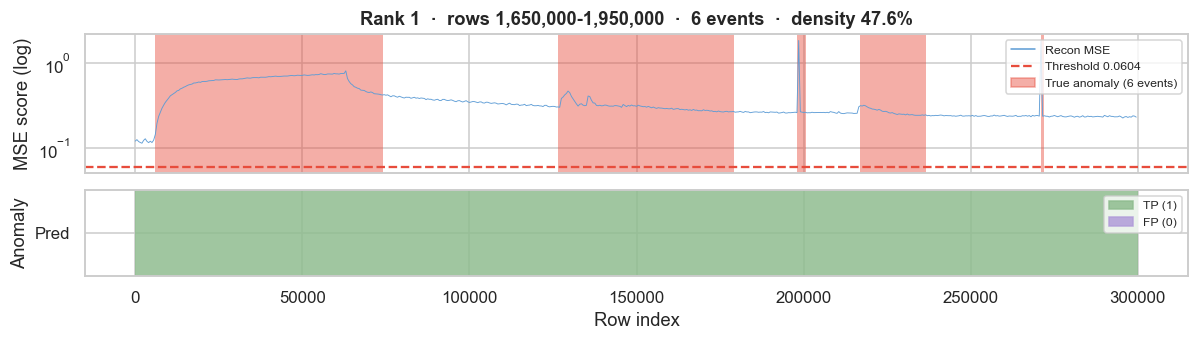

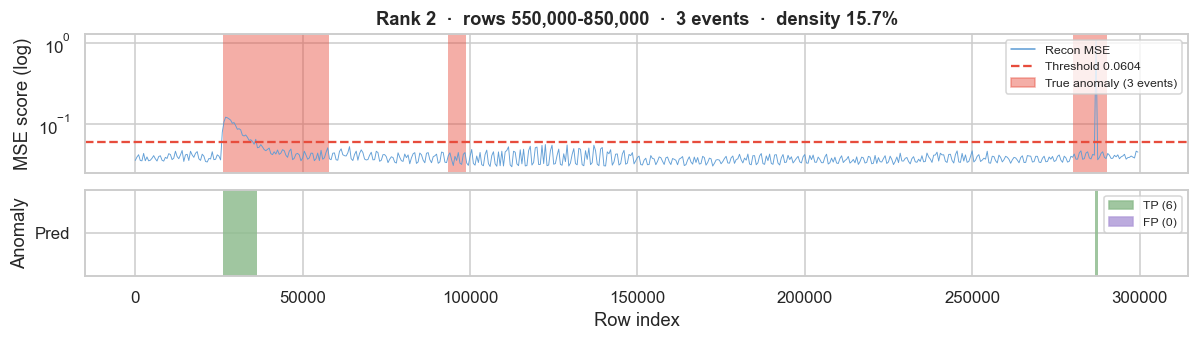

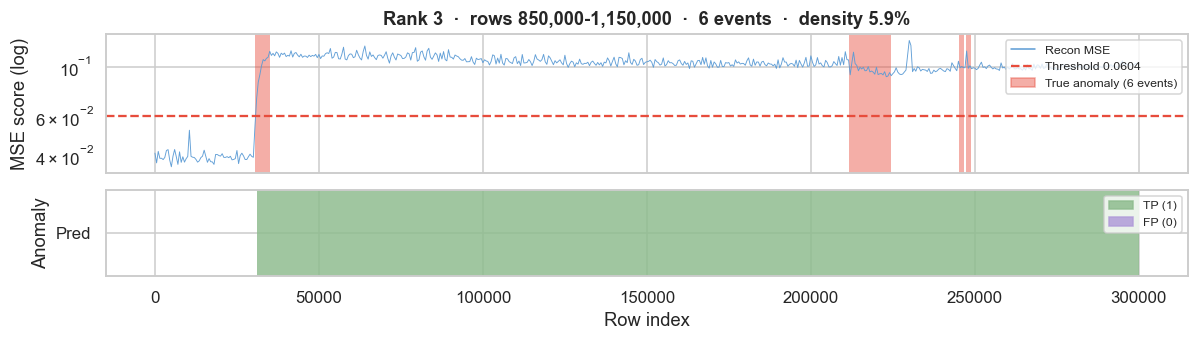

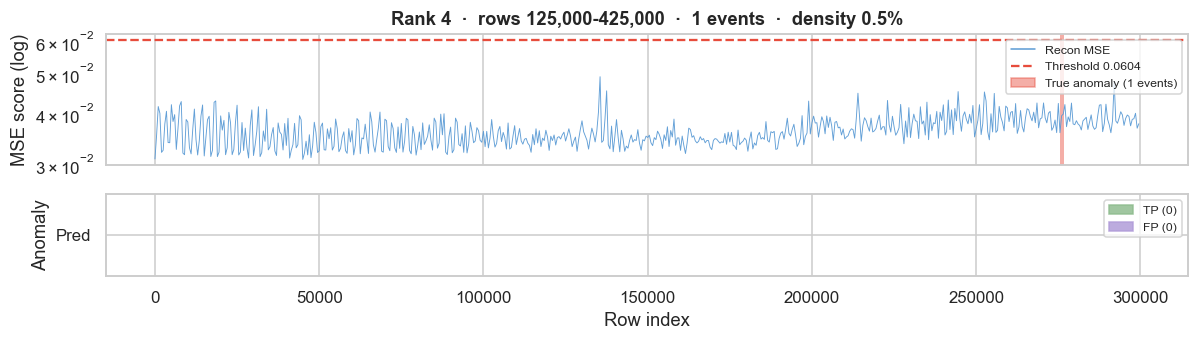

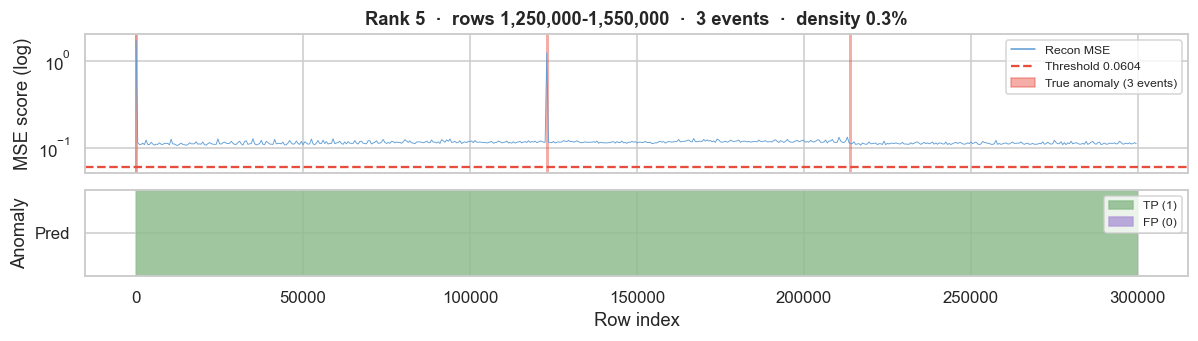

In [8]:
# Render plot_timeline for each picked slice. Compact figsize so all candidates
# fit on screen without scrolling. Scores/labels are reused from the full
# test_intern run above - identical to scoring the slice in isolation because
# slice boundaries are window-aligned.
for _, row in picked_df.iterrows():
    s, e = int(row['start']), int(row['end'])
    fig = plot_timeline(
        scores=scores[s:e],
        y_true=y_int[s:e],
        threshold=PCA_THRESHOLD,
        title=(f"Rank {int(row['rank'])}  ·  rows {s:,}-{e:,}  ·  "
               f"{int(row['n_events'])} events  ·  density {row['anomaly_rate']:.1%}"),
        log_y=True,
        figsize=(11, 3.2),
    )
    plt.show()


## 9 - Manual slice explorer

The ranked candidates use a fixed `SLICE_LEN` and `STRIDE` grid - good for
narrowing down a region but it can miss the exact start/end you'd like for the
demo. Drop arbitrary row IDs into `MANUAL_SLICES` to render any range you want
(no window alignment required for *viewing*; only enforce it before saving).
Each row's stats - event count, density - are recomputed against the full
`test_internal` arrays so they match what the API would see on that slice.

Manual slices:
 start     end  length  n_events  anomaly_rate  win_aligned
     0  150000  150000         2      0.000173         True
150000  900000  750000         5      0.070853         True
900000 1800000  900000         9      0.117319         True


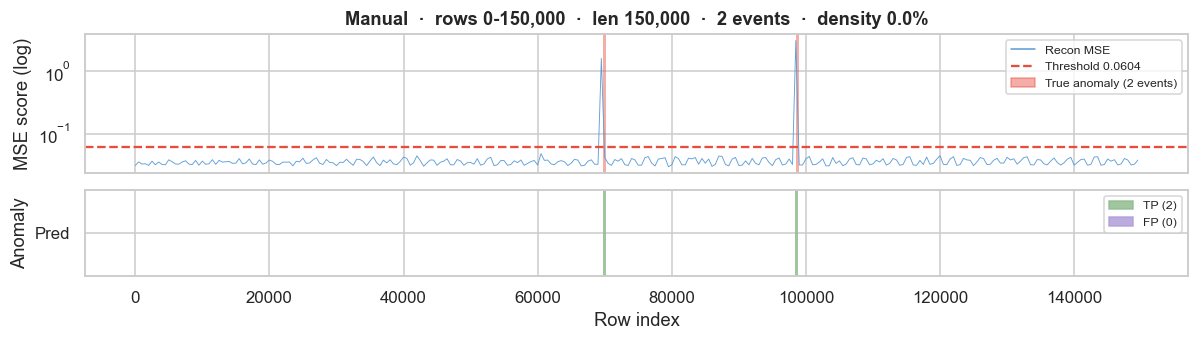

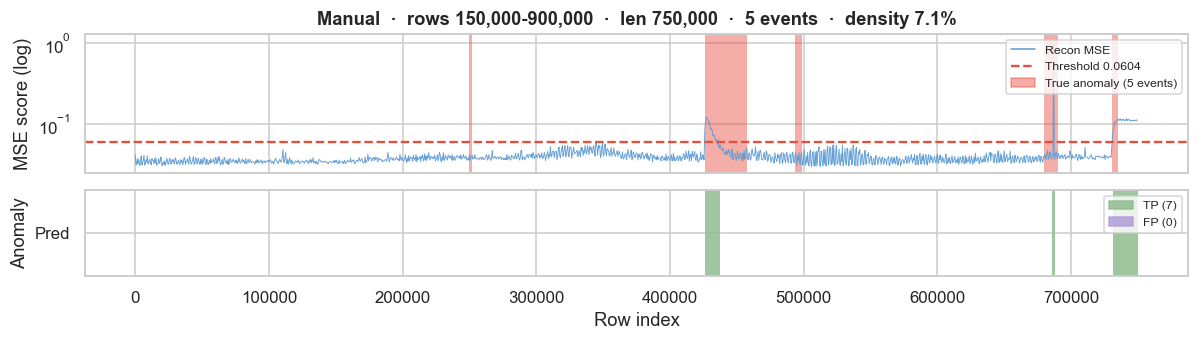

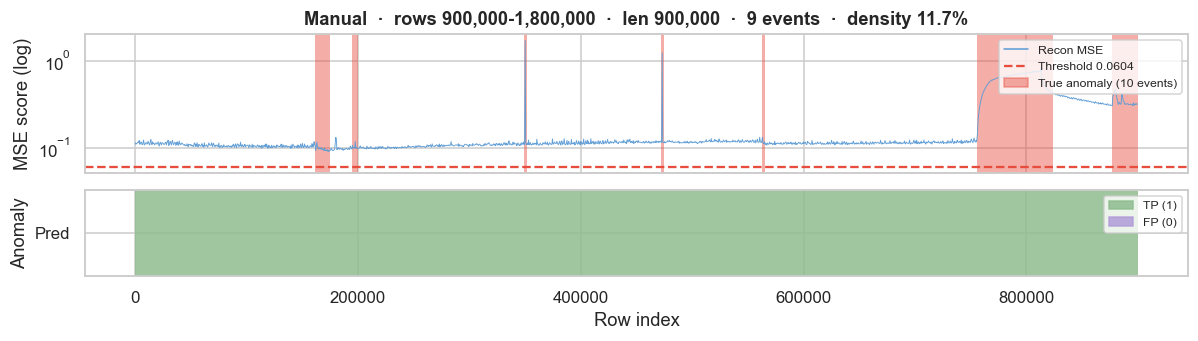

In [9]:
# Edit MANUAL_SLICES to whatever ranges you want to inspect.
# Each entry is (start_row, end_row); end is exclusive, like Python slicing.
MANUAL_SLICES = [
    (0, 150_000),
    (150_000, 900_000),
    (900_000, 1_800_000),
    # add your own ...
]

manual_rows = []
for s, e in MANUAL_SLICES:
    s, e = int(s), int(e)
    assert 0 <= s < e <= len(X_int), f'slice {s}-{e} out of bounds (max {len(X_int):,})'
    inside = (ev_starts >= s) & (ev_ends < e)
    manual_rows.append({
        'start'        : s,
        'end'          : e,
        'length'       : e - s,
        'n_events'     : int(inside.sum()),
        'anomaly_rate' : float(y_int[s:e].mean()),
        'win_aligned'  : (s % WINDOW_SIZE == 0) and (e % WINDOW_SIZE == 0),
    })
manual_df = pd.DataFrame(manual_rows)
print('Manual slices:')
print(manual_df.to_string(index=False))

# Render each manual slice. Same compact figsize as the ranked timelines.
for _, row in manual_df.iterrows():
    s, e = int(row['start']), int(row['end'])
    align_note = '' if row['win_aligned'] else '  (NOT window-aligned - fine for viewing, re-align before saving)'
    fig = plot_timeline(
        scores=scores[s:e],
        y_true=y_int[s:e],
        threshold=PCA_THRESHOLD,
        title=(f"Manual  ·  rows {s:,}-{e:,}  ·  len {e-s:,}  ·  "
               f"{int(row['n_events'])} events  ·  density {row['anomaly_rate']:.1%}"
               f"{align_note}"),
        log_y=True,
        figsize=(11, 3.2),
    )
    plt.show()


In [10]:
# Save a manually chosen slice. Set SAVE_START / SAVE_END directly to the row
# IDs you want, then uncomment the np.save lines. Both must be multiples of
# WINDOW_SIZE so the slice begins/ends on a PCA window boundary.
SAVE_START = 1_886_000
SAVE_END   = 2_186_000

assert SAVE_START % WINDOW_SIZE == 0 and SAVE_END % WINDOW_SIZE == 0, \
    f'slice must be window-aligned (multiple of {WINDOW_SIZE}); got {SAVE_START}, {SAVE_END}'
assert 0 <= SAVE_START < SAVE_END <= len(X_int), \
    f'slice {SAVE_START}-{SAVE_END} out of bounds (max {len(X_int):,})'

inside = (ev_starts >= SAVE_START) & (ev_ends < SAVE_END)
print(f'Slice rows {SAVE_START:,}-{SAVE_END:,}  (length {SAVE_END-SAVE_START:,})')
print(f'  events       : {int(inside.sum())}')
print(f'  anomaly rate : {y_int[SAVE_START:SAVE_END].mean():.2%}')

# Uncomment to save.
# from datetime import datetime
# ts = datetime.now().strftime('%Y%m%d_%H%M%S')
# np.save(PROCESSED_DIR / f'test_api_{ts}.npy',   X_int[SAVE_START:SAVE_END])
# np.save(PROCESSED_DIR / f'y_test_api_{ts}.npy', y_int[SAVE_START:SAVE_END])
# print(f'\nSaved: test_api_{ts}.npy  +  y_test_api_{ts}.npy')
# print('Replace the live files when you are happy:')
# print(f'  mv test_api_{ts}.npy   test_api.npy')
# print(f'  mv y_test_api_{ts}.npy y_test_api.npy')


Slice rows 1,886,000-2,186,000  (length 300,000)
  events       : 7
  anomaly rate : 1.92%
